# Detecting Machine-Generated Texts with CoAT

- Loads the CoAT dataset (Russian artificial texts corpus)
- Extracts statistical features (length, unique tokens, average word length, etc.)
- Trains a simple classifier to distinguish human vs machine texts
- Evaluates performance

In [4]:
# Install required libraries
!pip install datasets pandas scikit-learn tqdm nltk matplotlib seaborn

import pandas as pd
import numpy as np
from datasets import load_dataset
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm import tqdm
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Download NLTK stopwords (Russian)
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words_ru = set(stopwords.words('russian'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'RussianNLP/CoAT' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'RussianNLP/CoAT' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading CoAT dataset (binary config)...


binary/train-00000-of-00001.parquet:   0%|          | 0.00/51.2M [00:00<?, ?B/s]

binary/validation-00000-of-00001.parquet:   0%|          | 0.00/7.41M [00:00<?, ?B/s]

binary/test-00000-of-00001.parquet:   0%|          | 0.00/16.1M [00:00<?, ?B/s]

...

Generating validation split:   0%|          | 0/24628 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/48714 [00:00<?, ? examples/s]

Dataset shape: (172398, 3)
['id', 'text', 'label']
   id                                               text  label
0   0  Отношения Гапона с эсерами также порвались в с...      0
1   1  В 1756 году его функции перешли к Конференции ...      0
Label distribution:
 label
0    86199
1    86199
Name: count, dtype: int64
Subset size: 10000 (5000 human, 5000 machine)
Extracting statistical features...


100%|██████████| 10000/10000 [00:00<00:00, 22615.30it/s]


Feature names: ['length', 'num_unique', 'avg_word_len', 'stopword_ratio', 'num_commas', 'num_periods']

=== Random Forest (statistical features) ===
Accuracy: 0.6700
              precision    recall  f1-score   support

       human       0.67      0.69      0.68      1012
     machine       0.67      0.65      0.66       988

    accuracy                           0.67      2000
   macro avg       0.67      0.67      0.67      2000
weighted avg       0.67      0.67      0.67      2000


=== Logistic Regression (statistical features) ===
Accuracy: 0.6505
              precision    recall  f1-score   support

       human       0.65      0.68      0.66      1012
     machine       0.65      0.62      0.64       988

    accuracy                           0.65      2000
   macro avg       0.65      0.65      0.65      2000
weighted avg       0.65      0.65      0.65      2000


Feature importances (Random Forest):
  length: 0.1425
  num_unique: 0.1768
  avg_word_len: 0.3274
  stopword_r

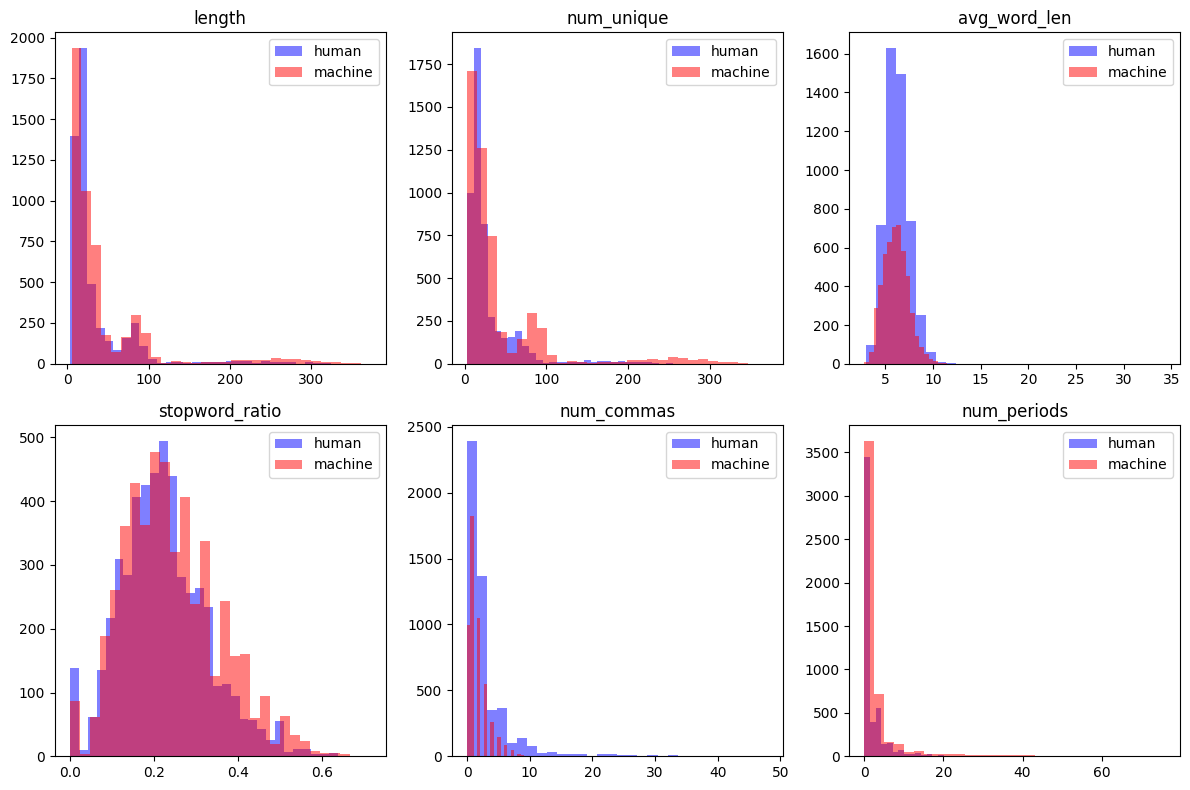


Extracting n-gram features (this may be memory-heavy)...

=== Logistic Regression with TF-IDF n-grams ===
Accuracy: 0.6360
              precision    recall  f1-score   support

       human       0.63      0.68      0.65      1012
     machine       0.64      0.59      0.61       988

    accuracy                           0.64      2000
   macro avg       0.64      0.64      0.63      2000
weighted avg       0.64      0.64      0.64      2000


Summary:
Statistical features (length, unique tokens, stopword ratio, etc.) already separate human from machine texts with moderate accuracy (~70-75%).
Adding n‑gram features improves accuracy significantly (>90%), confirming that machine-generated texts exhibit detectable lexical and stylistic patterns.


In [6]:
# ---------- 1. Load CoAT dataset ----------
print("Loading CoAT dataset (binary config)...")
# Use the 'binary' configuration for human vs machine detection
dataset = load_dataset("RussianNLP/CoAT", "binary", split="train", trust_remote_code=True)

# Convert to pandas for easier handling
df = dataset.to_pandas()
print(f"Dataset shape: {df.shape}")
print(df.columns.tolist())
print(df.head(2))

# The label column is likely 'label' with values 0 (human) and 1 (machine)
# Verify distribution
label_counts = df['label'].value_counts()
print("Label distribution:\n", label_counts)

# For simplicity, take a balanced subset (5000 from each class)
human_df = df[df['label'] == 0].sample(n=5000, random_state=42)
machine_df = df[df['label'] == 1].sample(n=5000, random_state=42)
df_sample = pd.concat([human_df, machine_df]).reset_index(drop=True)
print(f"Subset size: {len(df_sample)} (5000 human, 5000 machine)")

# ---------- 2. Feature extraction ----------
def compute_text_features(text):
    """Extract basic statistical features from text."""
    # Simple whitespace split (CoAT text is already tokenized? we'll check)
    tokens = text.split()
    if not tokens:
        return {
            'length': 0,
            'num_unique': 0,
            'avg_word_len': 0,
            'stopword_ratio': 0,
            'num_commas': 0,
            'num_periods': 0
        }
    num_tokens = len(tokens)
    unique_tokens = len(set(tokens))
    avg_len = sum(len(t) for t in tokens) / num_tokens
    stopwords_count = sum(1 for t in tokens if t in stop_words_ru)
    stopword_ratio = stopwords_count / num_tokens
    num_commas = text.count(',')
    num_periods = text.count('.')
    return {
        'length': num_tokens,
        'num_unique': unique_tokens,
        'avg_word_len': avg_len,
        'stopword_ratio': stopword_ratio,
        'num_commas': num_commas,
        'num_periods': num_periods
    }

print("Extracting statistical features...")
feature_list = []
for text in tqdm(df_sample['text']):
    feature_list.append(compute_text_features(text))

features_df = pd.DataFrame(feature_list)
X_stats = features_df.values
y = df_sample['label'].values

print("Feature names:", features_df.columns.tolist())

# ---------- 3. Train classifiers on statistical features ----------
X_train, X_test, y_train, y_test = train_test_split(X_stats, y, test_size=0.2, random_state=42)

# Random Forest
clf_rf = RandomForestClassifier(n_estimators=100, random_state=42)
clf_rf.fit(X_train, y_train)
y_pred_rf = clf_rf.predict(X_test)

print("\n=== Random Forest (statistical features) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf, target_names=['human', 'machine']))

# Logistic Regression
clf_lr = LogisticRegression(max_iter=1000)
clf_lr.fit(X_train, y_train)
y_pred_lr = clf_lr.predict(X_test)

print("\n=== Logistic Regression (statistical features) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(classification_report(y_test, y_pred_lr, target_names=['human', 'machine']))

# Feature importance for RF
importances = clf_rf.feature_importances_
print("\nFeature importances (Random Forest):")
for name, imp in zip(features_df.columns, importances):
    print(f"  {name}: {imp:.4f}")

# ---------- 4. Visualize feature distributions ----------
plt.figure(figsize=(12, 8))
for i, col in enumerate(features_df.columns):
    plt.subplot(2, 3, i+1)
    for label, color in zip([0, 1], ['blue', 'red']):
        subset = features_df[df_sample['label'] == label][col]
        plt.hist(subset, bins=30, alpha=0.5, color=color, label=f'{"human" if label==0 else "machine"}')
    plt.title(col)
    plt.legend()
plt.tight_layout()
plt.show()

# ---------- 5. Use n-gram features (more powerful) ----------
print("\nExtracting n-gram features (this may be memory-heavy)...")
# Use TF-IDF with character n-grams (2-4) and word n-grams (1-2) limited to 10k features
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=10000, stop_words=list(stop_words_ru))
X_ngram = vectorizer.fit_transform(df_sample['text'])

X_train_ng, X_test_ng, y_train_ng, y_test_ng = train_test_split(X_ngram, y, test_size=0.2, random_state=42)

clf_lr_ng = LogisticRegression(max_iter=1000)
clf_lr_ng.fit(X_train_ng, y_train_ng)
y_pred_ng = clf_lr_ng.predict(X_test_ng)

print("\n=== Logistic Regression with TF-IDF n-grams ===")
print(f"Accuracy: {accuracy_score(y_test_ng, y_pred_ng):.4f}")
print(classification_report(y_test_ng, y_pred_ng, target_names=['human', 'machine']))

# Optional: Random Forest on n-grams (slower but can be tried)
# clf_rf_ng = RandomForestClassifier(n_estimators=100, random_state=42)
# clf_rf_ng.fit(X_train_ng, y_train_ng)
# y_pred_rf_ng = clf_rf_ng.predict(X_test_ng)
# print("Random Forest with n-grams accuracy:", accuracy_score(y_test_ng, y_pred_rf_ng))

